# Levelling to a grid

In [1]:
# %load_ext autoreload
# %autoreload 2

import boule
import cmocean
import numpy as np
import pandas as pd
import polartoolkit as ptk
import verde as vd

import airbornegeo

/home/sungw937/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load survey data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_gravity_survey`, and the BAS processing steps are repeated in the notebook `processing_AGAP_gravity_survey`.

In [10]:
data_df = pd.read_csv("data/AGAP_gravity_survey_processed.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "unixtime",
        "distance_along_line",
        "grav_disturbance_filt",
    ]
]
data_df.head()

,easting,northing,height,line,unixtime,distance_along_line,grav_disturbance_filt
0,1.000024e+06,226237.330771,4156.1,1,1.229507e+09,0.000000,49.38
1,1.000083e+06,226246.631269,4156.0,1,1.229507e+09,59.842447,49.45
2,1.000142e+06,226255.809132,4156.1,1,1.229507e+09,119.693401,49.52
3,1.000201e+06,226264.969079,4156.4,1,1.229507e+09,179.545645,49.58
4,1.000260e+06,226274.156809,4156.6,1,1.229507e+09,239.285174,49.65


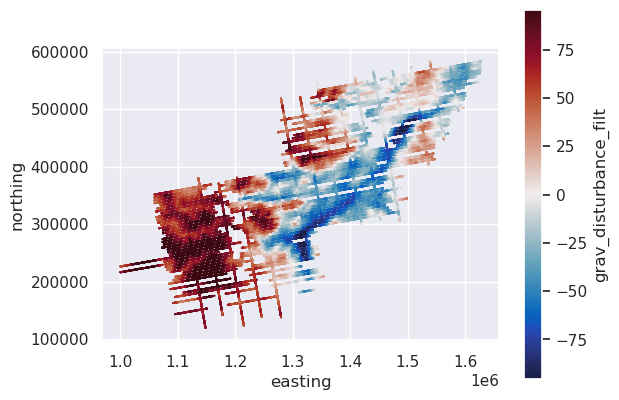

In [12]:
# plot the data
max_abs = vd.maxabs(data_df.grav_disturbance_filt, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filt",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

## Get a grid of gravity disturbance at 10km

In [13]:
# Download satellite gravity data from EIGEN-6C4 model
region = vd.get_region((data_df.easting, data_df.northing))
eigen = ptk.fetch.gravity(
    version="eigen",
    spacing=5e3,
    region=region,
    epsg="3031",
)
eigen_df = vd.grid_to_table(eigen)
eigen_df = eigen_df.rename(columns={"x": "easting", "y": "northing"})

# reproject from EPSG 3031 to lat lon
eigen_df["lon"], eigen_df["lat"] = airbornegeo.reproject(
    eigen_df.easting,
    eigen_df.northing,
    input_crs="EPSG:3031",
    output_crs="EPSG:4326",
)

# calculated normal gravity at all EIGEN observation locations
eigen_df["normal_gravity"] = boule.WGS84.normal_gravity(
    (None, eigen_df.lat, eigen_df.ellipsoidal_height),
)

# calculate gravity disturbance
eigen_df["disturbance"] = eigen_df.gravity - eigen_df.normal_gravity

# convert to a dataset
eigen_ds = eigen_df.set_index(["northing", "easting"]).to_xarray()

eigen_ds

<xarray.Dataset> Size: 479kB
Dimensions:             (northing: 94, easting: 127)
Coordinates:
  * northing            (northing) float64 752B 1.2e+05 1.25e+05 ... 5.85e+05
  * easting             (easting) float64 1kB 1e+06 1.005e+06 ... 1.63e+06
Data variables:
    ellipsoidal_height  (northing, easting) float32 48kB 1e+04 1e+04 ... 1e+04
    gravity             (northing, easting) float32 48kB 9.8e+05 ... 9.797e+05
    lon                 (northing, easting) float64 96kB 83.16 83.19 ... 70.26
    lat                 (northing, easting) float64 96kB -80.75 -80.7 ... -74.16
    normal_gravity      (northing, easting) float64 96kB 9.8e+05 ... 9.798e+05
    disturbance         (northing, easting) float64 96kB 38.05 38.12 ... -20.55

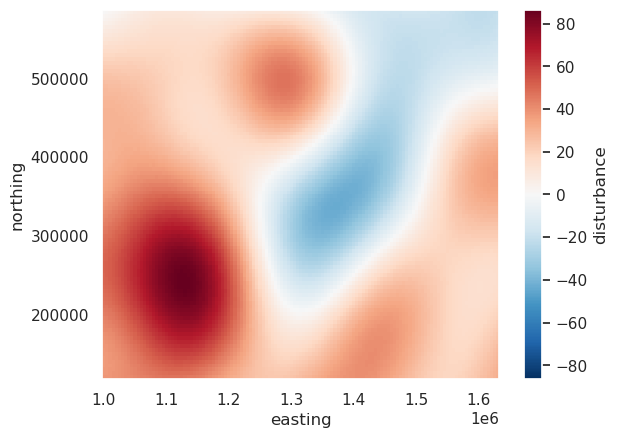

In [14]:
eigen_ds.disturbance.plot()

## Upward continue survey data to same height as gravity grid

In order to accurately compare the survey gravity data to the grid, the gravity data should be upward continued so it's at the same altitude.

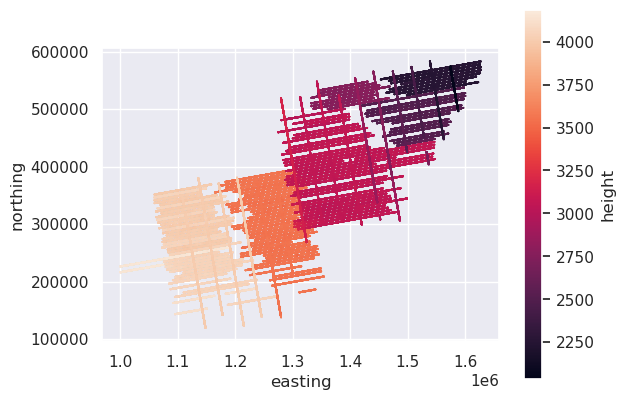

In [15]:
# plot the data
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="height",
    s=0.1,
)
ax.set_aspect("equal")

In [16]:
blocked_survey = airbornegeo.block_reduce(
    data_df,
    np.median,
    spacing=1000,
    reduce_by="distance_along_line",
    groupby_column="line",
)
blocked_survey

Segments: 100%|██████████| 100/100 [00:12<00:00,  7.99it/s]


,distance_along_line,easting,northing,height,unixtime,grav_disturbance_filt,line
0,477.521406,1.000496e+06,226310.158049,4159.10,1.229507e+09,49.890,1
1,1477.462561,1.001484e+06,226460.426302,4160.30,1.229507e+09,50.730,1
2,2504.019094,1.002497e+06,226630.494762,4156.00,1.229507e+09,51.090,1
3,3518.522095,1.003499e+06,226786.791629,4159.60,1.229507e+09,51.070,1
4,4528.427996,1.004498e+06,226936.380167,4165.70,1.229507e+09,51.430,1
...,...,...,...,...,...,...,...
21443,74604.147937,1.587227e+06,500746.382318,2091.50,1.230382e+09,-14.050,100
21444,75624.848269,1.587399e+06,499740.258279,2105.95,1.230382e+09,-16.245,100
21445,76638.943754,1.587565e+06,498740.092633,2110.60,1.230382e+09,-17.580,100
21446,77637.520664,1.587737e+06,497756.392340,2113.00,1.230382e+09,-17.820,100


In [17]:
# fit a set of equivalent sources to each line individually
eqs = airbornegeo.eq_sources_1d(
    blocked_survey,
    data_column="grav_disturbance_filt",
    depth="default",
    damping=None,
    block_size=1000,  # for speed, block reduce sources
    groupby_column="line",
)
eqs

Groups: 100%|██████████| 100/100 [00:14<00:00,  7.12it/s]


{1: EquivalentSources(block_size=1000),
 2: EquivalentSources(block_size=1000),
 3: EquivalentSources(block_size=1000),
 4: EquivalentSources(block_size=1000),
 5: EquivalentSources(block_size=1000),
 6: EquivalentSources(block_size=1000),
 7: EquivalentSources(block_size=1000),
 8: EquivalentSources(block_size=1000),
 9: EquivalentSources(block_size=1000),
 10: EquivalentSources(block_size=1000),
 11: EquivalentSources(block_size=1000),
 12: EquivalentSources(block_size=1000),
 13: EquivalentSources(block_size=1000),
 14: EquivalentSources(block_size=1000),
 15: EquivalentSources(block_size=1000),
 16: EquivalentSources(block_size=1000),
 17: EquivalentSources(block_size=1000),
 18: EquivalentSources(block_size=1000),
 19: EquivalentSources(block_size=1000),
 20: EquivalentSources(block_size=1000),
 21: EquivalentSources(block_size=1000),
 22: EquivalentSources(block_size=1000),
 23: EquivalentSources(block_size=1000),
 24: EquivalentSources(block_size=1000),
 25: EquivalentSources(bl

In [18]:
# upward continue each line to 10 km
blocked_survey["upward_continued_10km"] = airbornegeo.upward_continue_by_line(
    blocked_survey,
    eqs,
    height=10e3,
)
blocked_survey.head()

Groups: 100%|██████████| 100/100 [00:00<00:00, 158.69it/s]


,distance_along_line,easting,northing,height,unixtime,grav_disturbance_filt,line,upward_continued_10km
0,477.521406,1.000496e+06,226310.158049,4159.1,1.229507e+09,49.89,1,40.232278
1,1477.462561,1.001484e+06,226460.426302,4160.3,1.229507e+09,50.73,1,40.972657
2,2504.019094,1.002497e+06,226630.494762,4156.0,1.229507e+09,51.09,1,41.713109
3,3518.522095,1.003499e+06,226786.791629,4159.6,1.229507e+09,51.07,1,42.431563
4,4528.427996,1.004498e+06,226936.380167,4165.7,1.229507e+09,51.43,1,43.141623


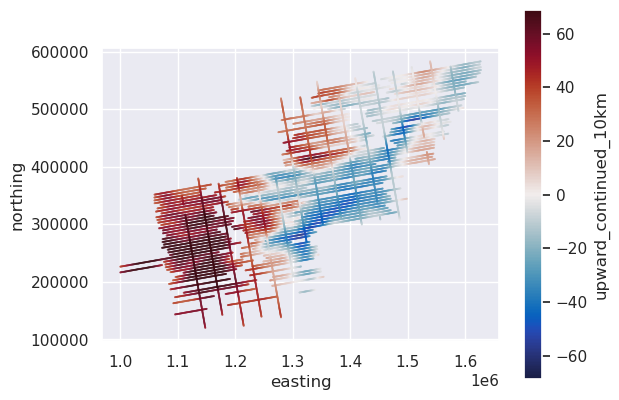

In [20]:
# plot the upward continued data
max_abs = vd.maxabs(blocked_survey.upward_continued_10km, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="upward_continued_10km",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

### Sample the satellite gravity grid values into the dataframe

In [21]:
# sample grid along lines
blocked_survey["sampled_grid_values"] = airbornegeo.sample_grid(
    blocked_survey,
    eigen_ds.disturbance,
    coord_names=("easting", "northing"),
)
blocked_survey.head()

grdtrack [WARNING]: Some input points were outside the grid domain(s).


,distance_along_line,easting,northing,height,unixtime,grav_disturbance_filt,line,upward_continued_10km,sampled_grid_values
0,477.521406,1.000496e+06,226310.158049,4159.1,1.229507e+09,49.89,1,40.232278,48.675663
1,1477.462561,1.001484e+06,226460.426302,4160.3,1.229507e+09,50.73,1,40.972657,48.836891
2,2504.019094,1.002497e+06,226630.494762,4156.0,1.229507e+09,51.09,1,41.713109,49.005095
3,3518.522095,1.003499e+06,226786.791629,4159.6,1.229507e+09,51.07,1,42.431563,49.172386
4,4528.427996,1.004498e+06,226936.380167,4165.7,1.229507e+09,51.43,1,43.141623,49.342525


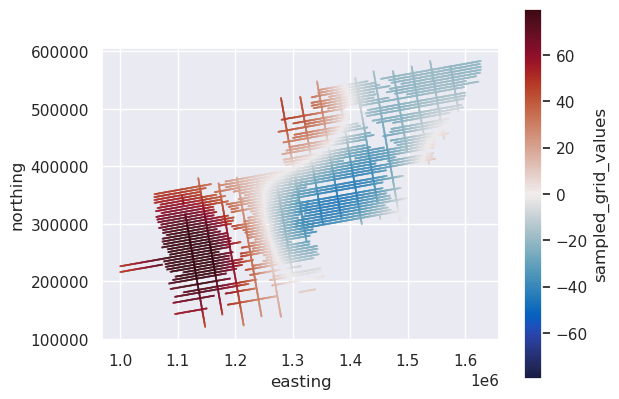

In [23]:
# plot the sampled grid values
max_abs = vd.maxabs(blocked_survey.sampled_grid_values, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="sampled_grid_values",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

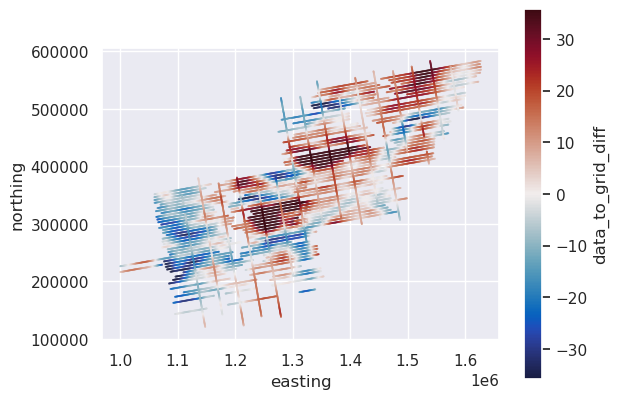

In [24]:
# plot the difference
blocked_survey["data_to_grid_diff"] = (
    blocked_survey.upward_continued_10km - blocked_survey.sampled_grid_values
)
max_abs = vd.maxabs(blocked_survey.data_to_grid_diff, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="data_to_grid_diff",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

## Level the lines to the grid

In [25]:
blocked_survey["levelled_trend_0"] = airbornegeo.level_to_grid(
    blocked_survey,
    degree=0,  # DC shift
    data_column="upward_continued_10km",
    grid_column="sampled_grid_values",
    groupby_column="line",
)
blocked_survey["levelled_trend_1"] = airbornegeo.level_to_grid(
    blocked_survey,
    degree=1,  # DC shift + tilt
    data_column="upward_continued_10km",
    grid_column="sampled_grid_values",
    groupby_column="line",
)
blocked_survey.head()

,distance_along_line,easting,northing,height,unixtime,grav_disturbance_filt,line,upward_continued_10km,sampled_grid_values,data_to_grid_diff,levelled_trend_0,levelled_trend_1
0,477.521406,1.000496e+06,226310.158049,4159.1,1.229507e+09,49.89,1,40.232278,48.675663,-8.443385,42.596650,39.485331
1,1477.462561,1.001484e+06,226460.426302,4160.3,1.229507e+09,50.73,1,40.972657,48.836891,-7.864234,43.337029,40.252951
2,2504.019094,1.002497e+06,226630.494762,4156.0,1.229507e+09,51.09,1,41.713109,49.005095,-7.291987,44.077481,41.021368
3,3518.522095,1.003499e+06,226786.791629,4159.6,1.229507e+09,51.07,1,42.431563,49.172386,-6.740823,44.795935,41.767460
4,4528.427996,1.004498e+06,226936.380167,4165.7,1.229507e+09,51.43,1,43.141623,49.342525,-6.200902,45.505995,42.505032


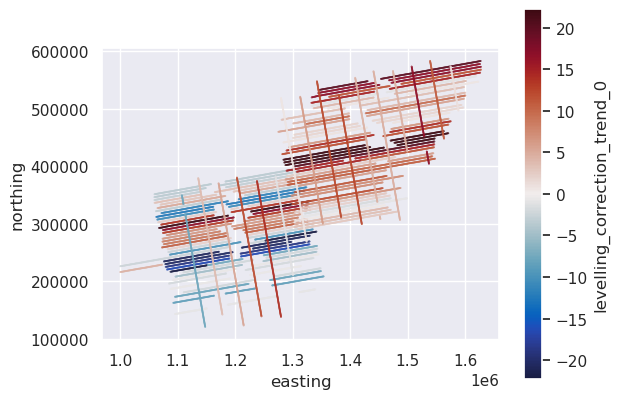

In [26]:
# plot the levelling correction
blocked_survey["levelling_correction_trend_0"] = (
    blocked_survey.upward_continued_10km - blocked_survey.levelled_trend_0
)
max_abs = vd.maxabs(blocked_survey.levelling_correction_trend_0, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction_trend_0",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

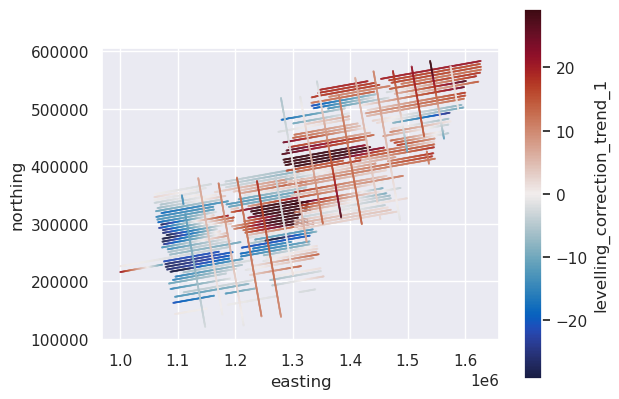

In [27]:
# plot the levelling correction
blocked_survey["levelling_correction_trend_1"] = (
    blocked_survey.upward_continued_10km - blocked_survey.levelled_trend_1
)
max_abs = vd.maxabs(blocked_survey.levelling_correction_trend_1, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction_trend_1",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

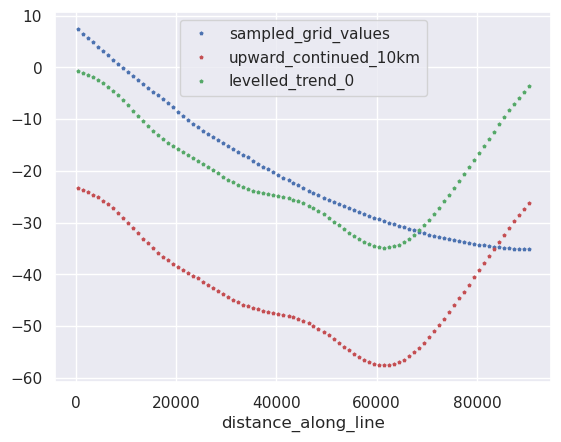

In [ ]:
# look at just 1 of the leveled lines
line_df = blocked_survey[blocked_survey.line == 2]
ax = line_df.plot.line(
    "distance_along_line",
    "sampled_grid_values",
    style="bp",
    ms=2,
)
ax = line_df.plot.line(
    "distance_along_line",
    "upward_continued_10km",
    style="rp",
    ms=2,
    ax=ax,
)
ax = line_df.plot.line(
    "distance_along_line",
    "levelled_trend_0",
    style="gp",
    ms=2,
    ax=ax,
)

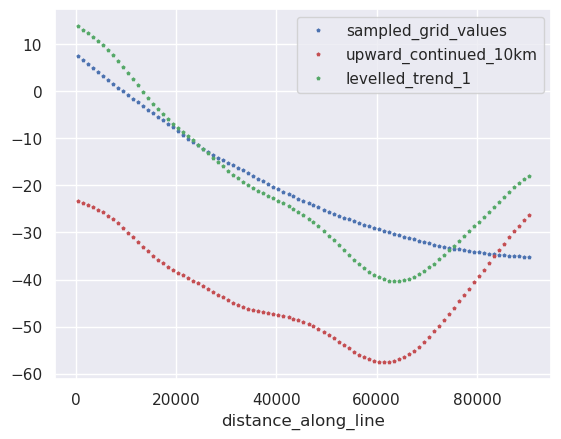

In [31]:
# look at just 1 of the leveled lines
line_df = blocked_survey[blocked_survey.line == 2]
ax = line_df.plot.line(
    "distance_along_line",
    "sampled_grid_values",
    style="bp",
    ms=2,
)
ax = line_df.plot.line(
    "distance_along_line",
    "upward_continued_10km",
    style="rp",
    ms=2,
    ax=ax,
)
ax = line_df.plot.line(
    "distance_along_line",
    "levelled_trend_1",
    style="gp",
    ms=2,
    ax=ax,
)

## Level the entire survey to the grid

By not supplying the `groupby_column` argument, instead of levelling each line in 1D, we can level the entire survey in 2D.

In [32]:
blocked_survey["levelled_trend_1"] = airbornegeo.level_to_grid(
    blocked_survey,
    degree=1,
    data_column="upward_continued_10km",
    grid_column="sampled_grid_values",
)
blocked_survey["levelled_trend_2"] = airbornegeo.level_to_grid(
    blocked_survey,
    degree=2,
    data_column="upward_continued_10km",
    grid_column="sampled_grid_values",
)
blocked_survey.head()

,distance_along_line,easting,northing,height,unixtime,grav_disturbance_filt,line,upward_continued_10km,sampled_grid_values,data_to_grid_diff,levelled_trend_0,levelled_trend_1,levelling_correction_trend_0,levelling_correction_trend_1,levelled_trend_2
0,477.521406,1.000496e+06,226310.158049,4159.1,1.229507e+09,49.89,1,40.232278,48.675663,-8.443385,42.596650,48.042236,-2.364372,0.746947,67.534014
1,1477.462561,1.001484e+06,226460.426302,4160.3,1.229507e+09,50.73,1,40.972657,48.836891,-7.864234,43.337029,48.749985,-2.364372,0.719706,68.053783
2,2504.019094,1.002497e+06,226630.494762,4156.0,1.229507e+09,51.09,1,41.713109,49.005095,-7.291987,44.077481,49.456755,-2.364372,0.691741,68.570103
3,3518.522095,1.003499e+06,226786.791629,4159.6,1.229507e+09,51.07,1,42.431563,49.172386,-6.740823,44.795935,50.142059,-2.364372,0.664103,69.066650
4,4528.427996,1.004498e+06,226936.380167,4165.7,1.229507e+09,51.43,1,43.141623,49.342525,-6.200902,45.505995,50.819190,-2.364372,0.636591,69.555997


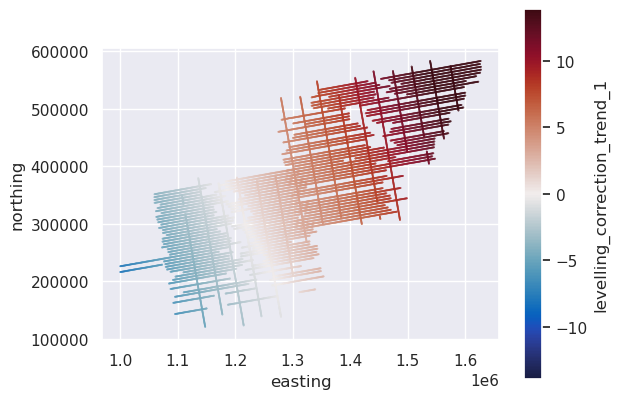

In [33]:
# plot the levelling correction
blocked_survey["levelling_correction_trend_1"] = (
    blocked_survey.upward_continued_10km - blocked_survey.levelled_trend_1
)
max_abs = vd.maxabs(blocked_survey.levelling_correction_trend_1, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction_trend_1",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

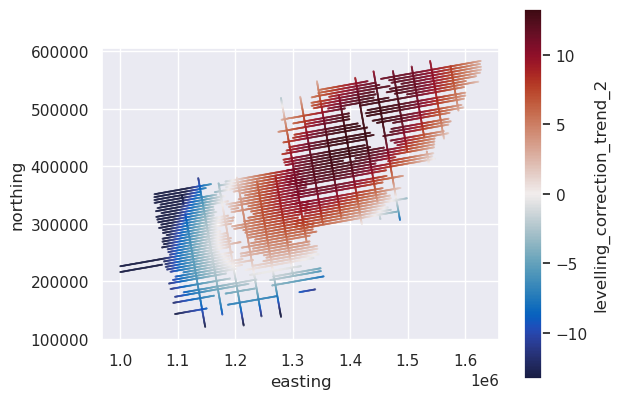

In [34]:
# plot the levelling correction
blocked_survey["levelling_correction_trend_2"] = (
    blocked_survey.upward_continued_10km - blocked_survey.levelled_trend_2
)
max_abs = vd.maxabs(blocked_survey.levelling_correction_trend_2, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction_trend_2",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")